# Network ReAct Agent - Demo Notebook
"Reasoning Loop with External State"

## Setup

In [1]:
import sys
from pathlib import Path

# Add src to path so we can import the package
sys.path.insert(0, str(Path.cwd().parent / "src"))

import json

from langchain_core.messages import HumanMessage

from network_manager_agent import (
    LLMConfig,
    build_agent,
    create_llm,
)
from network_manager_agent.data import DataManager

## Load Data

In [2]:
county_specialty_thresholds = {
    "mi": {
        "wayne": {"general practice": 10.0, "cardiology": 15.0},
        "washtenaw": {"general practice": 10.0, "cardiology": 15.0},
    }
}

dm = DataManager(county_specialty_thresholds=county_specialty_thresholds)
candidates = dm.get_candidates_df()
members = dm.get_members_df()
entity_summaries = dm.get_entity_summaries()
schema_profile = json.dumps(dm.get_schema_profile(), indent=2)

print(f"Loaded {len(candidates)} candidates, {len(members)} members, {len(entity_summaries)} entities")

Loaded 85615 candidates, 12051 members, 8609 entities


## Pre-compute: Filter & Aggregate (done by DataManager)

In [3]:
# DataManager handles loading, filtering, aggregation, and schema profiling automatically.
# See the Setup cell above for the current configuration.
print(f"Candidates: {len(dm.get_candidates_df())}, Members: {len(dm.get_members_df())}, Entities: {len(dm.get_entity_summaries())}")

Candidates: 85615, Members: 12051, Entities: 8609


## Create LLM

In [4]:
llm_config = LLMConfig(base_url="http://localhost:8080/v1")
llm = create_llm(llm_config)

# Quick test
response = llm.invoke("Hey there! Just making sure you're up and running!")
response.pretty_print()

================================== Ai Message ==================================

Hey there! 👋 Yep, I'm up and running and ready to go. What can I help you with today?


## Build Agent

In [5]:
import sqlite3
from pathlib import Path

from langgraph.checkpoint.sqlite import SqliteSaver

db_path = str(Path.cwd().parent / "checkpoints.sqlite")
conn = sqlite3.connect(db_path, check_same_thread=False)
checkpointer = SqliteSaver(conn)
agent = build_agent(llm, checkpointer=checkpointer)
print("Agent built successfully!")


Agent built successfully!


## Visualize Graph

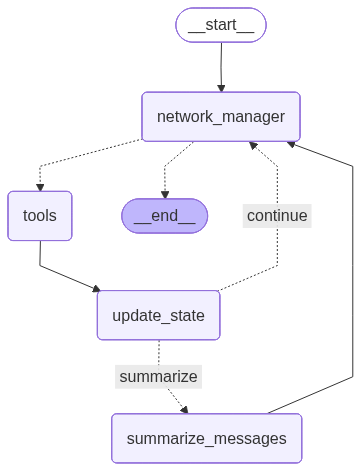

In [6]:
from IPython.display import Image, display
display(Image(agent.get_graph(xray=True).draw_mermaid_png()))


## Run the Agent

In [7]:
from network_manager_agent.ui import run_agent


def run_agent_demo(agent, inputs: dict, config: dict):
    """Wrapper for run_agent that matches the notebook's naming convention."""
    run_agent(agent, inputs, config)


In [8]:
# Create a thread
config = {"configurable": {"thread_id": "test_llama_cpp_mtp"}}


In [9]:
# Specify an input
messages = [HumanMessage(content='''
What is the entity with the most providers?
''')]

inputs = {
    "messages": messages,
    "county_specialty_thresholds": county_specialty_thresholds,
    "entity_summaries": entity_summaries,
    "schema_profile": schema_profile,
}

run_agent_demo(agent, inputs, config)


Starting Agent Execution...


>>>> NODE: network_manager <<<<
   --- TOOL CALL ---
   -> run_code({"code": "top_entity = entity_summaries_df.nlargest(1, \"provider_count\")[[\"entity\", \"provider_count\", \"avg_effectiveness\", \"avg_efficiency\", \"specialties\"]]\nresult = top_entity"})

>>>> NODE: tools <<<<
   --- TOOL RESULT (run_code) ---
    result: [{"entity": "mymichigan health", "provider_count": 8684, "avg_effectiveness": 3.213425983372627, "avg_efficiency": 3.265831675055601, "specialties": ["internal medicine", "cardiology", "family practice", "general surgery", "gastroenterology", "oncology - medical, surgical", "gynecology, ob/gyn", "pulmonology", "clinical social work", "neurology", "... and 35 more"]}]


>>>> NODE: network_manager <<<<
   --- CURRENT CONTENT ---
================================== Ai Message ==================================

The entity with the most providers is **mymichigan health**, which has **8,684 providers** across a wide range of specialties i

In [10]:
# Specify an input
messages = [HumanMessage(content='''
Ok, now find the entities within the service area for our network. Then, add the largest one by provider count. Then report back with the network coverage.
''')]

inputs = {
    "messages": messages
}

run_agent_demo(agent, inputs, config)


Starting Agent Execution...


>>>> NODE: network_manager <<<<
   --- TOOL CALL ---
   -> run_code({"code": "import pandas as pd\nimport numpy as np\nfrom scipy.spatial import BallTree\n\ntarget_counties = [\"wayne\", \"washtenaw\"]\ntarget_specs = [\"general practice\", \"cardiology\"]\n\ncounty_members = members_df[members_df[\"county\"].str.lower().isin(target_counties)]\nspec_candidates = candidates_df[candidates_df[\"specialty\"].str.lower().isin(target_specs)]\n\nvalid_provider_ids = set()\n\nfor spec in target_specs:\n    spec_provs = spec_candidates[spec_candidates[\"specialty\"].str.lower() == spec]\n    if spec_provs.empty:\n        continue\n        \n    tree = BallTree(np.deg2rad(spec_provs[[\"lat\", \"lon\"]]), metric=\"haversine\")\n    \n    for county in target_counties:\n        c_members = county_members[county_members[\"county\"].str.lower() == county]\n        if c_members.empty:\n            continue\n            \n        # Try to get threshold, handle case variat

In [15]:
# Specify an input
messages = [HumanMessage(content='''
Can you add another element to the score that factors in the number of providers? Recalculate and report back.
''')]

inputs = {
    "messages": messages
}

run_agent_demo(agent, inputs, config)

Starting Agent Execution...


>>>> NODE: network_manager <<<<
   --- TOOL CALL ---
   -> run_code({"code": "target_counties = [\"wayne\", \"washtenaw\"]\ntarget_specs = [\"general practice\", \"cardiology\"]\n\ntarget_members = members_df[members_df[\"county\"].str.lower().isin(target_counties)]\ntarget_candidates = candidates_df[candidates_df[\"specialty\"].str.lower().isin(target_specs)]\n\nentities_in_area = set()\n\nfor county in target_counties:\n    county_members = target_members[target_members[\"county\"].str.lower() == county]\n    if county_members.empty:\n        continue\n    for spec in target_specs:\n        spec_cands = target_candidates[target_candidates[\"specialty\"].str.lower() == spec]\n        if spec_cands.empty:\n            continue\n            \n        thresh = 10.0 if spec.lower() == \"general practice\" else 15.0\n        radius_rad = thresh / 3958.8\n        \n        tree = BallTree(np.deg2rad(spec_cands[[\"lat\", \"lon\"]].values), metric=\"haversine\")\

In [16]:
# Specify an input
messages = [HumanMessage(content='''
Why are the smaller ones so close in score to MyMichigan health?
''')]

inputs = {
    "messages": messages
}

run_agent_demo(agent, inputs, config)

Starting Agent Execution...


>>>> NODE: network_manager <<<<
   --- TOOL CALL ---
   -> run_code({"code": "target_counties = [\"wayne\", \"washtenaw\"]\ntarget_specs = [\"general practice\", \"cardiology\"]\n\ntarget_members = members_df[members_df[\"county\"].str.lower().isin(target_counties)]\ntarget_candidates = candidates_df[candidates_df[\"specialty\"].str.lower().isin(target_specs)]\n\nentities_in_area = set()\n\nfor county in target_counties:\n    county_members = target_members[target_members[\"county\"].str.lower() == county]\n    if county_members.empty:\n        continue\n    for spec in target_specs:\n        spec_cands = target_candidates[target_candidates[\"specialty\"].str.lower() == spec]\n        if spec_cands.empty:\n            continue\n            \n        thresh = 10.0 if spec.lower() == \"general practice\" else 15.0\n        radius_rad = thresh / 3958.8\n        \n        tree = BallTree(np.deg2rad(spec_cands[[\"lat\", \"lon\"]].values), metric=\"haversine\")\

In [18]:
# Specify an input
messages = [HumanMessage(content='''
I think we should do some scaling on the number of providers to make sure it's not being overpowered in the score. Suggest something, recalculate, and report back.
''')]

inputs = {
    "messages": messages
}

run_agent_demo(agent, inputs, config)

Starting Agent Execution...


>>>> NODE: network_manager <<<<
   --- TOOL CALL ---
   -> run_code({"code": "target_counties = [\"wayne\", \"washtenaw\"]\ntarget_specs = [\"general practice\", \"cardiology\"]\n\ntarget_members = members_df[members_df[\"county\"].str.lower().isin(target_counties)]\ntarget_candidates = candidates_df[candidates_df[\"specialty\"].str.lower().isin(target_specs)]\n\nentities_in_area = set()\n\nfor county in target_counties:\n    county_members = target_members[target_members[\"county\"].str.lower() == county]\n    if county_members.empty:\n        continue\n    for spec in target_specs:\n        spec_cands = target_candidates[target_candidates[\"specialty\"].str.lower() == spec]\n        if spec_cands.empty:\n            continue\n            \n        thresh = 10.0 if spec.lower() == \"general practice\" else 15.0\n        radius_rad = thresh / 3958.8\n        \n        tree = BallTree(np.deg2rad(spec_cands[[\"lat\", \"lon\"]].values), metric=\"haversine\")\

In [19]:
# Specify an input
messages = [HumanMessage(content='''
Now, simulate what would happen if added these recommendations to the network. Make a table that shows the potential coverage we could get, in order to compare how much each impacts coverage. 
''')]

inputs = {
    "messages": messages
}

run_agent_demo(agent, inputs, config)

Starting Agent Execution...


>>>> NODE: network_manager <<<<
   --- TOOL CALL ---
   -> run_code({"code": "base_cov, _ = compute_coverage(network_df, members_df, thresholds, candidates_df)\nbase_df = pd.DataFrame(base_cov)\n\ncandidates = [\n    \"oakland nocturnal physicians pllc\",\n    \"medical diagnostic services inc\",\n    \"mymichigan health\",\n    \"clinical cardiovascular care pc\",\n    \"james heinsimer md pc\"\n]\n\ncomparisons = []\nfor ent in candidates:\n    provs = candidates_df[candidates_df[\"entity\"].str.lower() == ent.lower()]\n    sim_net = pd.concat([network_df, provs])\n    sim_cov, _ = compute_coverage(sim_net, members_df, thresholds, candidates_df)\n    sim_df = pd.DataFrame(sim_cov)\n    \n    merged = pd.merge(base_df, sim_df, on=[\"state\", \"county\", \"specialty\"], suffixes=(\"_base\", \"_sim\"))\n    merged[\"delta_pp\"] = merged[\"coverage_percentage_sim\"] - merged[\"coverage_percentage_base\"]\n    merged[\"entity\"] = ent\n    comparisons.append(

## Inspect Agent State

In [20]:
# Show the last human message from the conversation
state = agent.get_state(config)
messages = state.values.get("messages", [])
last_human = [m for m in reversed(messages) if m.type == 'human']
print("Last human message:")
print(last_human[0].content if last_human else "(none)")


Last human message:

Now, simulate what would happen if added these recommendations to the network. Make a table that shows the potential coverage we could get, in order to compare how much each impacts coverage. 



In [21]:
print("Summary:")
print(state.values.get("summary", "(empty)"))
print()

print("Entity summaries in state:")
print(f"  {len(state.values.get('entity_summaries', []))} entities loaded")
print()

print("Schema profile:")
schema = state.values.get("schema_profile", "")
print(f"  {len(schema)} chars" if schema else "  (empty)")


Summary:
Objective: Find entities within the service area for the network. Then show me the top 5 entities based on a balanced score of effectiveness, efficiency, and new patient acceptance rate.

Progress: Initial query successfully retrieved and ranked entities despite a transient `ImportError`. User requested adding provider count as a fourth dimension to the balanced score. Tool was executed to recalculate rankings using normalized metrics across all four dimensions. A follow-up tool call provided the exact normalized component scores to explain the mathematical proximity between large-scale and small-scale entities. System execution is now stable and ready for coverage simulation.

Key Findings: 
- Recalculated top 5 entities now incorporate provider count into the balanced score:
  - MyMichigan Health: 8,684 providers, avg_effectiveness 3.213425983372627, avg_efficiency 3.265831675055601, new_patient_rate 88.82%, balanced_score 0.7520036036517642
  - Medical Diagnostic Services I

In [22]:
import pandas as pd
print("Current network (list of entity IDs):")
network = agent.get_state(config).values.get("network", [])
if network:
    for i, entity_id in enumerate(network, 1):
        print(f"  {i}. {entity_id}")
else:
    print("  (empty - no entities added yet)")


Current network (list of entity IDs):
  (empty - no entities added yet)


## Try a More Complex Prompt

In [ ]:
# Reset with a new thread
# config = {"configurable": {"thread_id": "2"}}

messages = [HumanMessage(content='''
OK, now I'd like to add one more contract entity to the network. But I'd like to make sure this one has high effectiveness, but also one that best adds to the coverage. Find one, add it, and then report back on the status of the network.
''')]

inputs = {
    "messages": messages,
    "county_specialty_thresholds": county_specialty_thresholds,
    "entity_summaries": entity_summaries,
    "schema_profile": schema_profile,
}

run_agent_demo(agent, inputs, config)


In [ ]:
# Check final state
state = agent.get_state(config)
print("Summary:")
print(state.values.get("summary", "(empty)"))

print("\nNetwork (entity IDs):")
network = state.values.get("network", [])
if network:
    for i, entity_id in enumerate(network, 1):
        print(f"  {i}. {entity_id}")
else:
    print("  (empty)")
